
# Task 1: Exploratory Data Analysis (EDA) on Titanic Dataset

## Project Overview

Exploratory Data Analysis (EDA) is the process of examining and understanding a dataset using statistical summaries, data cleaning techniques, and visualizations.

In this project, I will analyze the Titanic passenger dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn.

## Objectives

- Load and understand the Titanic dataset.
- Explore the dataset using Pandas DataFrame operations.
- Identify and handle missing values and duplicate records.
- Perform grouping and aggregation to discover patterns.
- Analyze survival rates based on passenger characteristics.
- Visualize important trends and relationships.
- Summarize the key findings from the analysis.



## 1. Importing Libraries

First, I import the required Python libraries.

- **Pandas:** Data manipulation and analysis.
- **NumPy:** Numerical operations.
- **Matplotlib:** Creating charts and plots.
- **Seaborn:** Statistical data visualization.

These libraries provide the tools needed to inspect, clean, analyze, and visualize the dataset.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")


## 2. Loading the Dataset

The Titanic dataset contains information about passengers, including age, gender, passenger class, ticket fare, embarkation port, and survival status.

I load the dataset into a Pandas DataFrame using `read_csv()`. I also examine its dimensions to understand the number of records and features available for analysis.


In [4]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 891
Columns: 12



## 3. Initial Data Inspection

I use the following Pandas functions to understand the structure and contents of the dataset:

- `head()` displays the first five rows.
- `tail()` displays the last five rows.
- `info()` provides column names, data types, and non-null counts.
- `describe()` generates descriptive statistics.
- `shape` returns the number of rows and columns.
- `columns` lists the available features.

This initial inspection helps identify the types of variables and potential data quality issues.


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [10]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [11]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [12]:
print("Columns in the dataset:")

for column in df.columns:
    print(column)

Columns in the dataset:
PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked



## 4. Missing Value Analysis and Treatment

Missing values can affect statistical analysis and the reliability of conclusions. I identify missing entries using `isnull().sum()` and calculate their percentages for each column.

I then handle missing values using appropriate strategies:

- **Age:** Replace missing values with the median.
- **Embarked:** Replace missing values with the most frequent category (mode).
- **Cabin:** Replace missing values with the label `"Unknown"`.

The median is less sensitive to extreme values than the mean, while the mode is suitable for categorical data. Retaining unknown cabin information avoids unnecessarily removing passenger records.

Finally, I verify the remaining missing values.


In [13]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000



## 5. Duplicate Record Analysis

Duplicate records can lead to inaccurate counts and misleading statistical summaries.

I use `duplicated().sum()` to identify completely duplicated rows and `drop_duplicates()` to remove them. After cleaning, I check the dataset again to verify whether any exact duplicate rows remain.

Note that identical values across selected columns do not necessarily mean two passenger records are duplicates; this check concerns entire rows.


In [15]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [16]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (891, 12)


In [20]:
age_median = df["Age"].median()

df["Age"] = df["Age"].fillna(age_median)

embarked_mode = df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(embarked_mode)

df["Cabin"] = df["Cabin"].fillna("Unknown")

In [21]:
print("Missing values after cleaning:")

df.isnull().sum()

Missing values after cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



## 5. Duplicate Record Analysis

Duplicate records can lead to inaccurate counts and misleading statistical summaries.

I use `duplicated().sum()` to identify completely duplicated rows and `drop_duplicates()` to remove them. After cleaning, I check the dataset again to verify whether any exact duplicate rows remain.

Note that identical values across selected columns do not necessarily mean two passenger records are duplicates; this check concerns entire rows.


In [22]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0



## 6. Exploring Unique Values

I examine the unique values in each column to understand the categories and value ranges present in the dataset.

This helps identify categorical variables, understand encoded values, and spot unexpected entries that may require further investigation.


In [23]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


PassengerId:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Survived:
[0 1]

Pclass:
[3 1 2]

Name:
['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry' 'Moran, Mr. James' 'McCarthy, Mr. Timothy J'
 'Palsson, Master. Gosta Leonard'
 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)'
 'Nasser, Mrs. Nicholas (Adele Achem)' 'Sandstrom, Miss. Marguerite Rut'
 'Bonnell, Miss. Elizabeth' 'Saundercock, Mr. William Henry'
 'Andersson, Mr. Anders Johan' 'Vestrom, Miss. Hulda Amanda Adolfina'
 'Hewlett, Mrs. (Mary D Kingcome) ' 'Rice, Master. Eugene'
 'Williams, Mr. Charles Eugene'
 'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)'
 'Masselmani, Mrs. Fatima']

Sex:
['male' 'female']

Age:
[22. 38. 26. 35. 28. 54.  2. 27. 14.  4. 58. 20. 39. 55. 31. 34. 15.  8.
 19. 40.]

SibSp:
[1 0 3 4 2 5 8]

Parch:
[0 1 2 5 3 4 6]

Ticket:
['A/5 21171' 'PC


## 7. Survival Distribution

The `Survived` column indicates whether a passenger survived the Titanic disaster:

- `0`: Did not survive.
- `1`: Survived.

I calculate the number and percentage of survivors and non-survivors. I also examine the gender distribution to understand the composition of the passenger population.


In [24]:
survival_counts = df["Survived"].value_counts()

print("Survival counts:")
print(survival_counts)

survival_percentage = df["Survived"].value_counts(normalize=True) * 100

print("Survival percentage:")
print(survival_percentage.round(2))

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64
Survival percentage:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [25]:
gender_counts = df["Sex"].value_counts()

print("Number of passengers by gender:")
print(gender_counts)

Number of passengers by gender:
Sex
male      577
female    314
Name: count, dtype: int64



## 8. Survival Analysis by Gender

I group passengers by gender and calculate the total number of passengers, survivors, and survival rate.

Using `groupby()` and `agg()`, I compare survival rates between male and female passengers. This analysis helps identify differences in survival outcomes across gender groups.


In [26]:
survival_by_gender = df.groupby("Sex")["Survived"].agg(
    ["count", "sum", "mean"]
)

survival_by_gender.columns = [
    "Passengers",
    "Survivors",
    "Survival_Rate"
]

survival_by_gender["Survival_Rate"] = (
    survival_by_gender["Survival_Rate"] * 100
).round(2)

survival_by_gender

,Passengers,Survivors,Survival_Rate
Sex,,,
female,314,233,74.20
male,577,109,18.89



## 9. Survival Analysis by Passenger Class

The `Pclass` column represents the passenger's ticket class:

- `1`: First class.
- `2`: Second class.
- `3`: Third class.

I calculate passenger counts, average age, average fare, survivor counts, and survival rates for each class.

I also group the data by passenger class and gender to investigate how these two characteristics relate to survival outcomes.


In [27]:
class_analysis = df.groupby("Pclass").agg(
    Passengers=("PassengerId", "count"),
    Average_Age=("Age", "mean"),
    Average_Fare=("Fare", "mean"),
    Survivors=("Survived", "sum"),
    Survival_Rate=("Survived", "mean")
)

class_analysis["Survival_Rate"] = (
    class_analysis["Survival_Rate"] * 100
).round(2)

class_analysis

,Passengers,Average_Age,Average_Fare,Survivors,Survival_Rate
Pclass,,,,,
1,216,36.812130,84.154687,136,62.96
2,184,29.765380,20.662183,87,47.28
3,491,25.932627,13.675550,119,24.24


In [28]:
class_gender_analysis = df.groupby(
    ["Pclass", "Sex"]
).agg(
    Passengers=("PassengerId", "count"),
    Survivors=("Survived", "sum"),
    Average_Fare=("Fare", "mean"),
    Survival_Rate=("Survived", "mean")
)

class_gender_analysis["Survival_Rate"] = (
    class_gender_analysis["Survival_Rate"] * 100
).round(2)

class_gender_analysis

Passengers  Survivors  Average_Fare  Survival_Rate
Pclass Sex                                                       
1      female          94         91    106.125798          96.81
       male           122         45     67.226127          36.89
2      female          76         70     21.970121          92.11
       male           108         17     19.741782          15.74
3      female         144         72     16.118810          50.00
       male           347         47     12.661633          13.54


## 10. Age and Fare Statistics

I analyze age and ticket fare using descriptive statistics such as count, mean, median, minimum, maximum, and standard deviation.

I also compare age statistics between survivors and non-survivors. This provides an overview of passenger demographics and fare distributions.


In [29]:
age_survival_analysis = df.groupby("Survived")["Age"].agg(
    ["count", "mean", "median", "min", "max"]
)

age_survival_analysis

,count,mean,median,min,max
Survived,,,,,
0,549,30.028233,28.0,1.00,74.0
1,342,28.291433,28.0,0.42,80.0


In [30]:
fare_analysis = df["Fare"].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

fare_analysis

,Fare
count,891.000000
mean,32.204208
median,14.454200
min,0.000000
max,512.329200
std,49.693429



## 11. Analysis by Embarkation Port

The `Embarked` column represents the port where a passenger boarded the ship.

I group passengers by embarkation port and calculate passenger counts, survivors, average fares, and survival rates.

This analysis helps explore differences in passenger composition and survival outcomes across embarkation categories.


In [31]:
embarked_analysis = df.groupby("Embarked").agg(
    Passengers=("PassengerId", "count"),
    Survivors=("Survived", "sum"),
    Average_Fare=("Fare", "mean"),
    Survival_Rate=("Survived", "mean")
)

embarked_analysis["Survival_Rate"] = (
    embarked_analysis["Survival_Rate"] * 100
).round(2)

embarked_analysis

,Passengers,Survivors,Average_Fare,Survival_Rate
Embarked,,,,
C,168,93,59.954144,55.36
Q,77,30,13.276030,38.96
S,646,219,27.243651,33.90



## 12. Family Size and Survival Analysis

I calculate family size by adding the number of siblings or spouses (`SibSp`) and parents or children (`Parch`), plus one for the passenger.

I then categorize passengers into three groups:

- **Alone:** Family size of 1.
- **Small Family:** Family size between 2 and 4.
- **Large Family:** Family size greater than 4.

I compare passenger counts and survival rates across family sizes and categories to explore whether traveling alone or with family was associated with different survival outcomes.


In [32]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [33]:
family_analysis = df.groupby("FamilySize").agg(
    Passengers=("PassengerId", "count"),
    Survivors=("Survived", "sum"),
    Survival_Rate=("Survived", "mean")
)

family_analysis["Survival_Rate"] = (
    family_analysis["Survival_Rate"] * 100
).round(2)

family_analysis

,Passengers,Survivors,Survival_Rate
FamilySize,,,
1,537,163,30.35
2,161,89,55.28
3,102,59,57.84
4,29,21,72.41
5,15,3,20.00
6,22,3,13.64
7,12,4,33.33
8,6,0,0.00
11,7,0,0.00


In [34]:
def family_category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small Family"
    else:
        return "Large Family"

df["FamilyCategory"] = df["FamilySize"].apply(family_category)

df[["FamilySize", "FamilyCategory"]].head()

,FamilySize,FamilyCategory
0,2,Small Family
1,2,Small Family
2,1,Alone
3,2,Small Family
4,1,Alone


In [35]:
family_category_analysis = df.groupby("FamilyCategory").agg(
    Passengers=("PassengerId", "count"),
    Survivors=("Survived", "sum"),
    Survival_Rate=("Survived", "mean")
)

family_category_analysis["Survival_Rate"] = (
    family_category_analysis["Survival_Rate"] * 100
).round(2)

family_category_analysis

,Passengers,Survivors,Survival_Rate
FamilyCategory,,,
Alone,537,163,30.35
Large Family,62,10,16.13
Small Family,292,169,57.88



## 13. Data Visualization

Visualizations make it easier to understand patterns and distributions in the dataset.

I use Seaborn and Matplotlib to create:

- A survival distribution count plot.
- A comparison of survival by gender.
- A comparison of survival by passenger class.
- An age distribution histogram.
- A fare distribution histogram.
- A scatter plot showing age and fare in relation to survival.

These charts complement the numerical analysis and help communicate findings clearly.


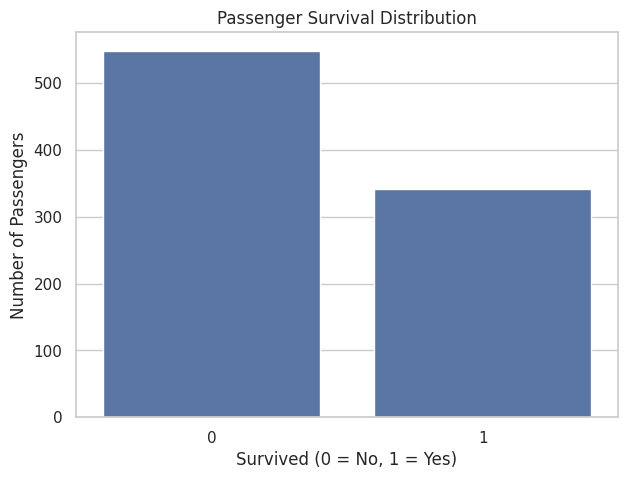

In [36]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Survived")

plt.title("Passenger Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

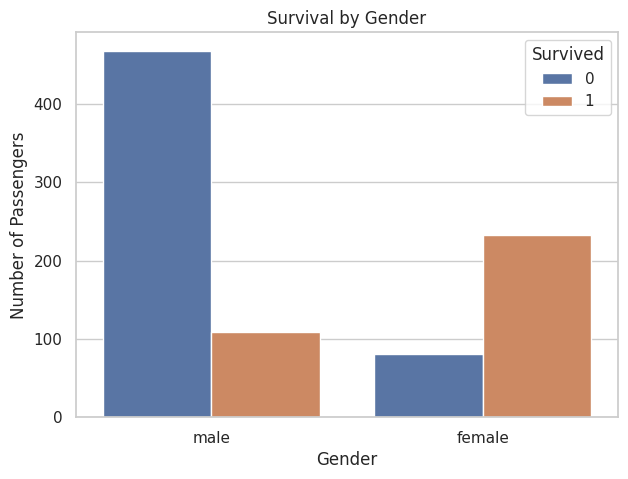

In [37]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

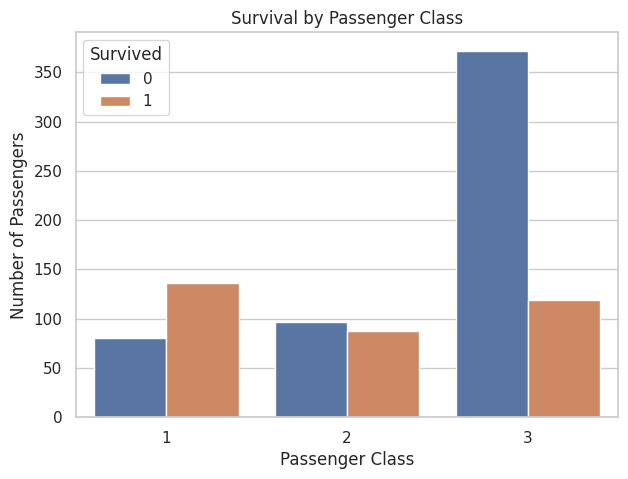

In [38]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

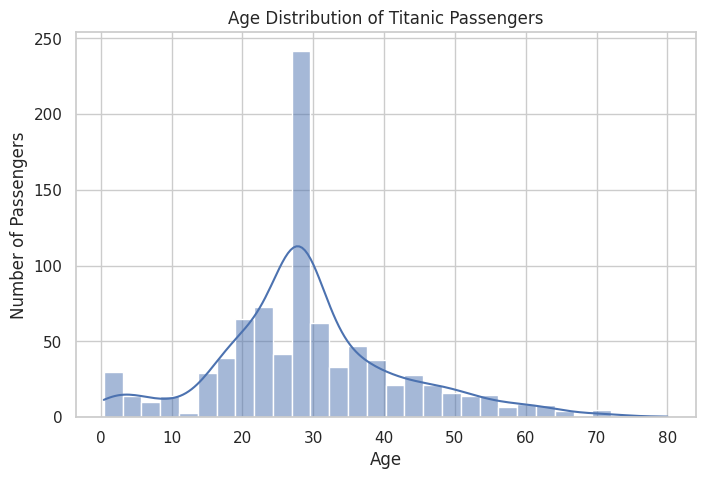

In [39]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

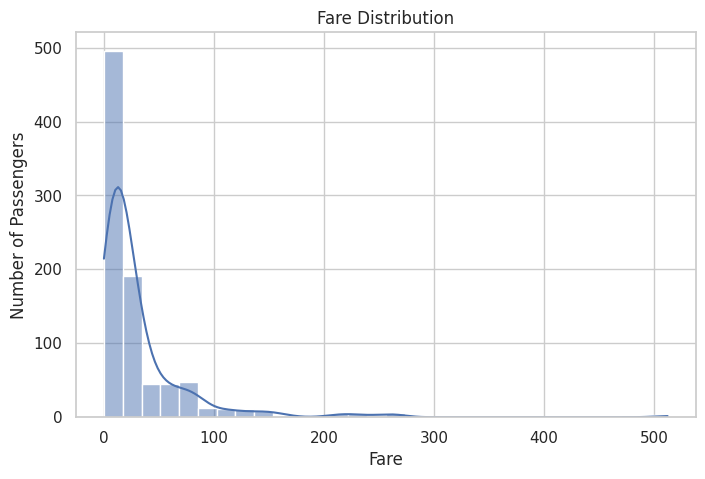

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

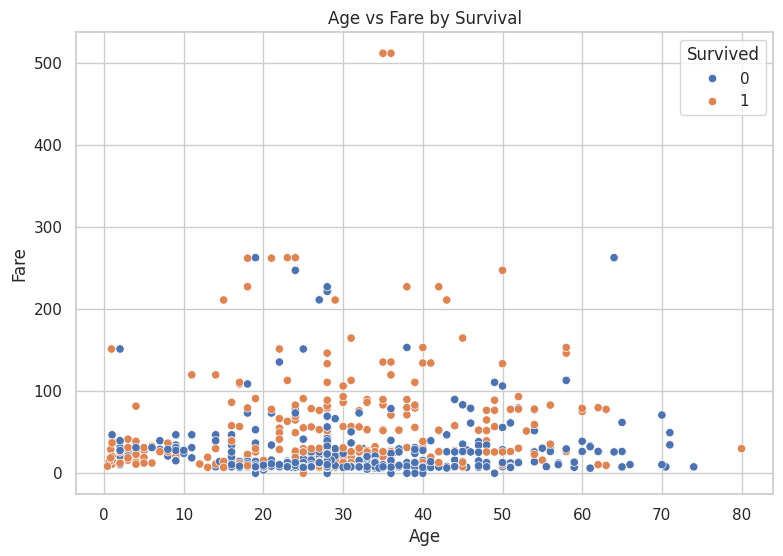

In [41]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()


## 14. Correlation Analysis

Correlation measures the strength and direction of a linear relationship between numerical variables.

I calculate a correlation matrix for selected numerical features and visualize it using a heatmap.

This helps identify possible relationships between survival, passenger class, age, family size, and fare. Correlation does not necessarily imply causation, and encoded categorical variables require careful interpretation.


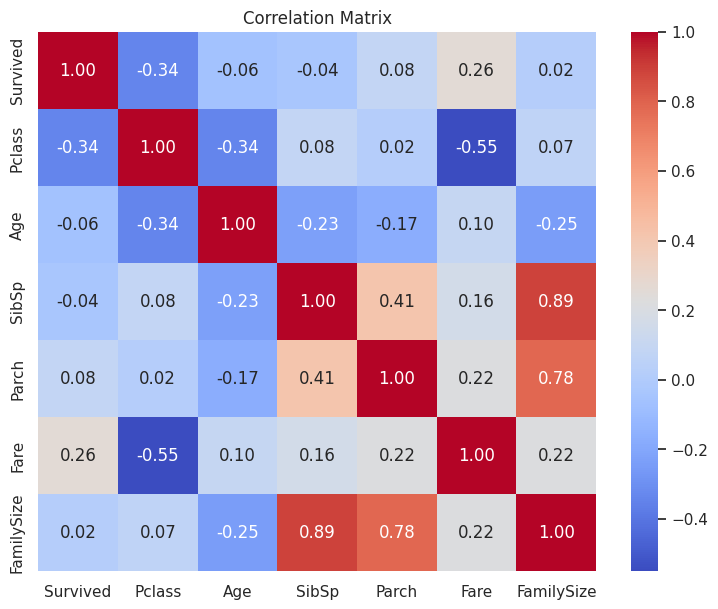

In [43]:
numerical_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()


## 15. Conclusion

In this project, I performed Exploratory Data Analysis on the Titanic dataset using Python.

The analysis covered:

- Dataset loading and inspection using Pandas.
- Statistical summaries using `describe()`.
- Identification and treatment of missing values.
- Duplicate record detection and removal.
- Grouping and aggregation using `groupby()` and `agg()`.
- Survival analysis based on gender, passenger class, age, embarkation port, and family size.
- Data visualization and correlation analysis.

The analysis demonstrates how data cleaning, descriptive statistics, aggregation, and visualization can be used to understand a dataset and discover patterns.

The observed relationships describe associations in this dataset and should not automatically be interpreted as causal relationships.
